In [1]:
# Cell 1: Imports and Device Configuration
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import copy

# Enable cuDNN benchmark for optimized convolutions (speedup for fixed input sizes)
torch.backends.cudnn.benchmark = True

# Check for GPU (CUDA or MPS for Apple Silicon), otherwise use CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs available: {torch.cuda.device_count()}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS device")
else:
    device = torch.device("cpu")
    print("WARNING: Using CPU. Training will be slow.")

Using Apple MPS device


In [2]:
# Cell 2: Configuration and Hyperparameters
# --- UPDATE THIS PATH TO YOUR DATASET FOLDER ---
DATA_DIR = r'/Users/kethniimasha/Desktop/FYP Final Project/2000_per_class_256x256_Grayscale_split' # Inside this folder, you should have your 6 or 7 class folders

BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 150
PATIENCE = 10 # For Early Stopping
IMAGE_SIZE = (128, 128) # Resize all images to this size
VALIDATION_SPLIT = 0.2 # 20% of data used for validation

In [3]:
# Cell 3: Data Augmentation and Loaders
# Define transforms (Data Augmentation for training, standard for validation)
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = None

# Load the entire dataset
try:
    full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
    num_classes = len(full_dataset.classes)
    class_names = full_dataset.classes
    print(f"Successfully loaded dataset.")
    print(f"Found {num_classes} classes: {class_names}")
except FileNotFoundError:
    print(f"Error: Dataset not found at {DATA_DIR}. Please update the path in Cell 2.")
    num_classes = 2 # Fallback to prevent crash during setup

# Split into Training and Validation sets
val_size = int(len(full_dataset) * VALIDATION_SPLIT)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# SPEEDUP CRITICAL: pin_memory=True and num_workers (set to 4-8 depending on your CPU cores)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
    num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
    num_workers=4, pin_memory=True
)

print(f"Training images: {train_size} | Validation images: {val_size}")

Successfully loaded dataset.
Found 2 classes: ['train', 'val']
Training images: 14463 | Validation images: 3615


In [4]:
# Cell 4: Model Building
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc_layers(x)
        return x

# Instantiate model
model = CustomCNN(num_classes=num_classes)

# PARALLELIZE: If multiple GPUs are available, wrap the model to use all of them
if torch.cuda.device_count() > 1:
    print(f"Parallelizing across {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# Move model to device
model = model.to(device)
print(model)

CustomCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_feature

In [5]:
# Cell 5: Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, path='best_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.path = path

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            # Save the best model
            torch.save(model.state_dict(), self.path)
            print(f"  --> Validation loss decreased. Saving model.")
        else:
            self.counter += 1
            print(f"  --> EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [6]:
# Cell 6: Initialization
criterion = nn.CrossEntropyLoss()

# Adam optimizer with weight decay (L2 Regularization) for overfitting prevention
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

early_stopping = EarlyStopping(patience=PATIENCE, path='best_cnn_weights.pth')

# Dictionaries to store metrics for plotting
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

In [7]:
# Cell 7: Training Loop with AMP and tqdm
from tqdm import tqdm  # Make sure to import tqdm

print("Starting Training with Mixed Precision and Progress Tracking...")

# Initialize GradScaler for AMP (prevents underflow when using 16-bit floats)
scaler = torch.cuda.amp.GradScaler()

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # Wrap the train_loader with tqdm
    train_loop = tqdm(train_loader, leave=False, desc=f"Epoch [{epoch+1}/{EPOCHS}] Train")
    
    for images, labels in train_loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
        # Update the progress bar with the current loss
        train_loop.set_postfix(loss=loss.item())
        
    epoch_train_loss = running_train_loss / train_size
    epoch_train_acc = correct_train / total_train
    
    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # Wrap the val_loader with tqdm
    val_loop = tqdm(val_loader, leave=False, desc=f"Epoch [{epoch+1}/{EPOCHS}] Val  ")
    
    with torch.no_grad():
        for images, labels in val_loop:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
            # Update the progress bar with the current loss
            val_loop.set_postfix(loss=loss.item())
            
    epoch_val_loss = running_val_loss / val_size
    epoch_val_acc = correct_val / total_val
    
    # Store metrics
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    # Print the final summary for the epoch
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")
    
    # Check Early Stopping
    early_stopping(epoch_val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered. Training halted.")
        break

# Load the best weights back
model.load_state_dict(torch.load('best_cnn_weights.pth'))
print("Training Completed. Best model weights loaded.")

/var/folders/c5/cy1l3b0d44d063cpmm65hspc0000gp/T/ipykernel_63346/1369026516.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/opt/anaconda3/lib/python3.13/site-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


Starting Training with Mixed Precision and Progress Tracking...


Epoch [1/150] Train:   0%|          | 0/452 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/var/folders/c5/cy1l3b0d44d063cpmm65hspc0000gp/T/ipykernel_63346/1369026516.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/opt/anaconda3/lib/python3.13/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch [1/150] Val  :   0%|          | 0/113 [00:00<?, ?it/s]                      /var/folders/c5/cy1l3b0d44d063cpmm65hspc0000gp/T/ipykernel_63346/1369026516.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with tor

Epoch [1/150] Train Loss: 0.8558, Train Acc: 0.7110 | Val Loss: 0.5882, Val Acc: 0.7281
  --> Validation loss decreased. Saving model.


Epoch [2/150] Train Loss: 0.6041, Train Acc: 0.7261 | Val Loss: 0.5973, Val Acc: 0.7278
  --> EarlyStopping counter: 1 out of 10


...

Epoch [23/150] Train Loss: 0.5870, Train Acc: 0.7266 | Val Loss: 0.5855, Val Acc: 0.7281
  --> EarlyStopping counter: 6 out of 10


Epoch [24/150] Train Loss: 0.5871, Train Acc: 0.7266 | Val Loss: 0.5852, Val Acc: 0.7281
  --> EarlyStopping counter: 7 out of 10


Epoch [25/150] Train Loss: 0.5867, Train Acc: 0.7266 | Val Loss: 0.5852, Val Acc: 0.7281
  --> EarlyStopping counter: 8 out of 10


Epoch [26/150] Train Loss: 0.5866, Train Acc: 0.7266 | Val Loss: 0.5854, Val Acc: 0.7281
  --> EarlyStopping counter: 9 out of 10


Epoch [27/150] Train Loss: 0.5870, Train Acc: 0.7266 | Val Loss: 0.5852, Val Acc: 0.7281
  --> EarlyStopping counter: 10 out of 10
Early stopping triggered. Training halted.
Training Completed. Best model weights loaded.


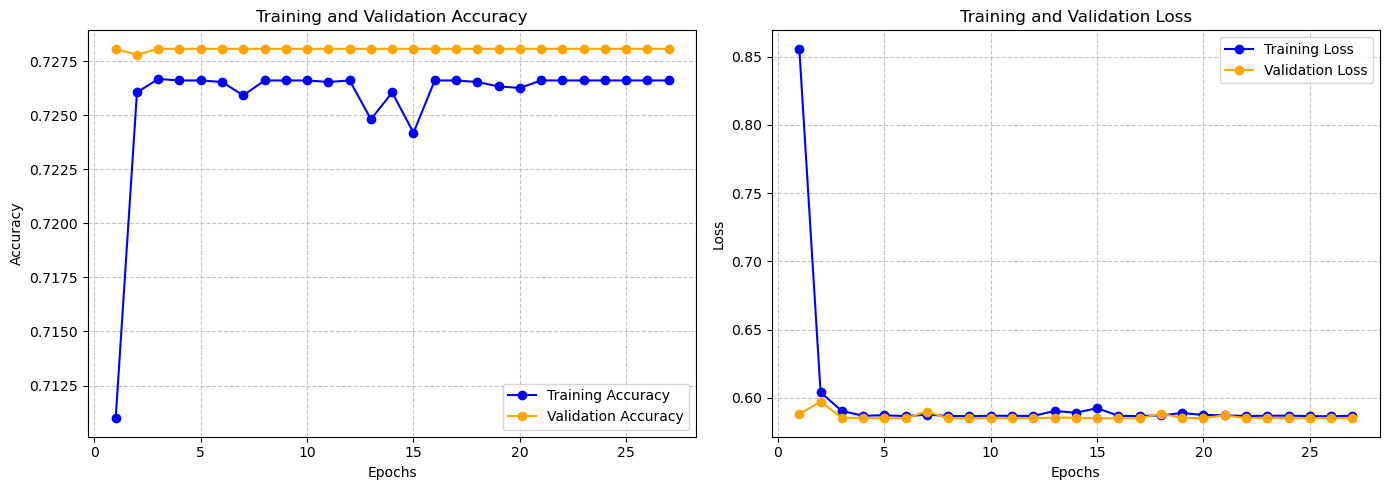

In [8]:
# Cell 8: Plotting Accuracy and Loss Graphs
epochs_run = len(history['train_loss'])
epochs_range = range(1, epochs_run + 1)

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='orange', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()